<a href="https://colab.research.google.com/github/fbnlb/fbnlb/blob/main/An%C3%A1lisis_nanopart%C3%ADculas_l%C3%ADpidicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PASO 1: DEFINICIÓN DE PARÁMETROS DEL MODELO
  - C_LNP_ext (extracelular) = 1.0 u.a.
  - k_release (liberación)   = 0.1 1/h
  - k_deg_mRNA (degradación ARNm) = 0.1 1/h
  - k_trans (traducción)     = 10.0 proteínas/ARNm/h
  - k_deg_prot (degradación proteína) = 0.05 1/h
  - k_uptake_base (captación) = 0.05 1/h
  - f_escape_base (escape)   = 0.02 (1.5-3% típico)


PASO 2: SISTEMA DE ECUACIONES DIFERENCIALES A RESOLVER
El sistema se compone de 3 variables de estado:
  y[0] = C_LNP_int  (concentración de LNP internalizada)
  y[1] = C_mRNA_citosol (ARNm liberado al citosol)
  y[2] = C_prot     (proteína expresada)

Ecuaciones:
  dC_LNP_int/dt  = k_uptake * C_LNP_ext - k_release * C_LNP_int
  dC_mRNA_citosol/dt = f_escape * k_release * C_LNP_int - k_deg_mRNA * C_mRNA_citosol
  dC_prot/dt = k_trans * C_mRNA_citosol - k_deg_prot * C_prot


PASO 3: CONFIGURACIÓN DE LA SIMULACIÓN NUMÉRICA
  - Tiempo total de simulación: 48.0 horas
  - Puntos de integración: 200
  - Tiempos clave para extracción d

/tmp/ipykernel_1040/804222499.py:173: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC_prot = np.trapz(C_prot_base, t_fino)
/tmp/ipykernel_1040/804222499.py:174: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC_mRNA = np.trapz(C_mRNA_base, t_fino)
/tmp/ipykernel_1040/804222499.py:228: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(C_prot, t_fino)
/tmp/ipykernel_1040/804222499.py:245: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(C_prot, t_fino)
/tmp/ipykernel_1040/804222499.py:275: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions 

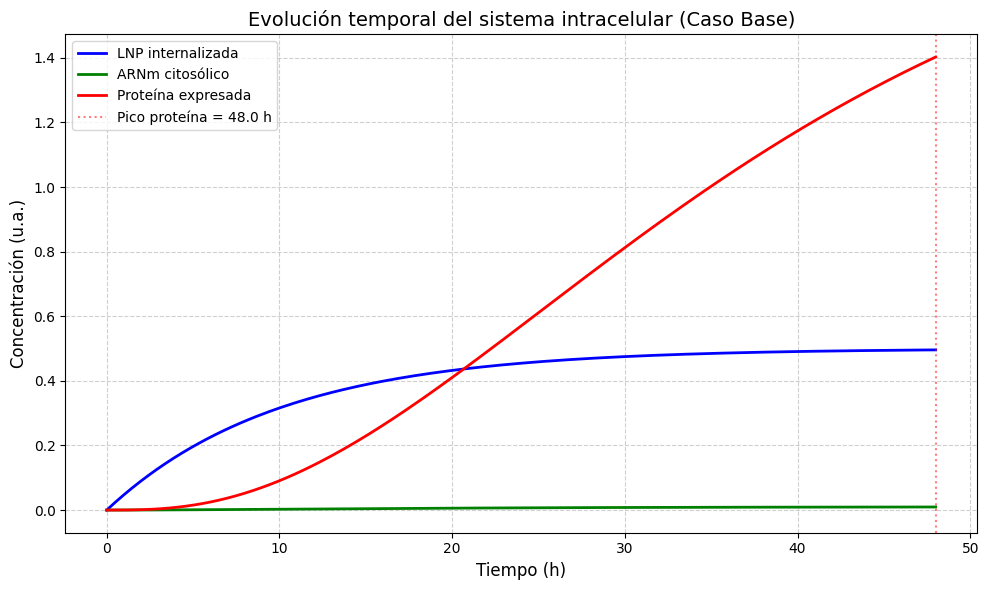

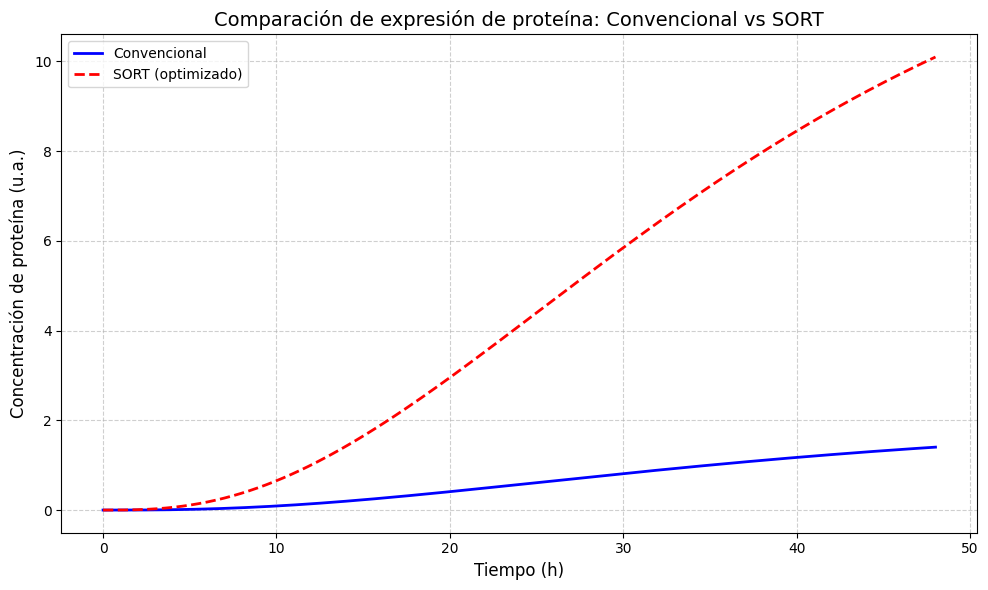

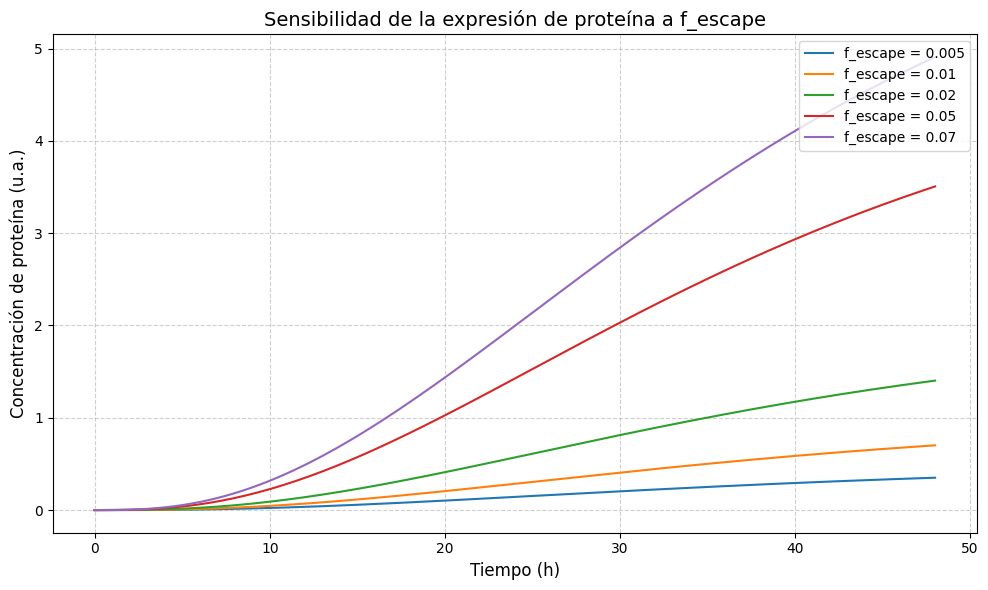


PASO 10: DETALLE DEL MÉTODO DE RESOLUCIÓN NUMÉRICA
  - El sistema se resuelve con `scipy.integrate.odeint`, que utiliza la
    biblioteca FORTRAN `LSODA` (Livermore Solver for Ordinary Differential
    Equations with Automatic method switching).
  - LSODA alterna entre métodos Adams (no rígido) y BDF (rígido) según
    la rigidez del sistema, lo que garantiza precisión y estabilidad.
  - La integración se realiza sobre un intervalo de [0, 48] horas con
    200 puntos de salida.
  - Las condiciones iniciales se definen como y0 = [0, 0, 0].
  - La tolerancia absoluta y relativa por defecto son 1.49e-8 y 1.49e-8,
    respectivamente, asegurando alta precisión.

  - Para la extracción en tiempos clave se utiliza interpolación lineal
    con `numpy.interp`, lo que proporciona valores exactos en los
    tiempos solicitados sin necesidad de refinar la malla.

ANÁLISIS CRÍTICO Y RECOMENDACIONES
Limitaciones del modelo:
  1. Se asume cinética de primer orden (lineal) para todos los procesos,
 

In [ ]:
# -*- coding: utf-8 -*-
"""
MODELO CINÉTICO INTRACELULAR DE LNP PARA ENTREGA DE ARNm
Grupo 4 - Proyecto Biotransporte (Avance #3)

Sistema de 3 EDOs:
dC_LNP_int/dt  = k_uptake * C_LNP_ext - k_release * C_LNP_int
dC_mRNA_citosol/dt = f_escape * k_release * C_LNP_int - k_deg_mRNA * C_mRNA_citosol
dC_prot/dt = k_trans * C_mRNA_citosol - k_deg_prot * C_prot

El código resuelve el sistema, muestra el paso a paso y genera tablas.
"""

# =============================================================================
# 1. IMPORTAR LIBRERÍAS
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pandas as pd

# Configurar pandas para mostrar todas las columnas
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 2. DEFINICIÓN DE PARÁMETROS (basados en la literatura)
# =============================================================================
# Se imprimen en pantalla para mostrar el paso a paso
print("="*80)
print("PASO 1: DEFINICIÓN DE PARÁMETROS DEL MODELO")
print("="*80)

# Parámetros fijos
C_LNP_ext = 1.0          # Concentración extracelular de LNP (u.a.)
k_release = 0.10         # Constante de liberación de ARNm desde LNP (1/h)
k_deg_mRNA = 0.10        # Constante de degradación de ARNm en citosol (1/h)
k_trans = 10.0           # Tasa de traducción (proteínas por ARNm por hora)
k_deg_prot = 0.05        # Constante de degradación de proteína (1/h)

# Parámetros base que variaremos en sensibilidad
k_uptake_base = 0.05     # Constante de captación base (1/h)
f_escape_base = 0.02     # Fracción de escape endosomal base (2%)

print(f"  - C_LNP_ext (extracelular) = {C_LNP_ext} u.a.")
print(f"  - k_release (liberación)   = {k_release} 1/h")
print(f"  - k_deg_mRNA (degradación ARNm) = {k_deg_mRNA} 1/h")
print(f"  - k_trans (traducción)     = {k_trans} proteínas/ARNm/h")
print(f"  - k_deg_prot (degradación proteína) = {k_deg_prot} 1/h")
print(f"  - k_uptake_base (captación) = {k_uptake_base} 1/h")
print(f"  - f_escape_base (escape)   = {f_escape_base} (1.5-3% típico)")
print("\n")

# =============================================================================
# 3. DEFINICIÓN DEL SISTEMA DE EDOs
# =============================================================================
print("="*80)
print("PASO 2: SISTEMA DE ECUACIONES DIFERENCIALES A RESOLVER")
print("="*80)
print("El sistema se compone de 3 variables de estado:")
print("  y[0] = C_LNP_int  (concentración de LNP internalizada)")
print("  y[1] = C_mRNA_citosol (ARNm liberado al citosol)")
print("  y[2] = C_prot     (proteína expresada)")
print("\nEcuaciones:")
print("  dC_LNP_int/dt  = k_uptake * C_LNP_ext - k_release * C_LNP_int")
print("  dC_mRNA_citosol/dt = f_escape * k_release * C_LNP_int - k_deg_mRNA * C_mRNA_citosol")
print("  dC_prot/dt = k_trans * C_mRNA_citosol - k_deg_prot * C_prot")
print("\n")

def modelo_lnp(y, t, k_uptake, f_escape):
    """
    Función que define el sistema de EDOs.
    y = [C_LNP_int, C_mRNA_citosol, C_prot]
    """
    C_LNP_int, C_mRNA_citosol, C_prot = y

    # Ecuación 1: LNP internalizada
    dC_LNP_int = k_uptake * C_LNP_ext - k_release * C_LNP_int

    # Ecuación 2: ARNm en citosol (escape endosomal - degradación)
    dC_mRNA_citosol = f_escape * k_release * C_LNP_int - k_deg_mRNA * C_mRNA_citosol

    # Ecuación 3: Proteína (traducción - degradación)
    dC_prot = k_trans * C_mRNA_citosol - k_deg_prot * C_prot

    return [dC_LNP_int, dC_mRNA_citosol, dC_prot]

# =============================================================================
# 4. CONFIGURACIÓN DE LA SIMULACIÓN
# =============================================================================
print("="*80)
print("PASO 3: CONFIGURACIÓN DE LA SIMULACIÓN NUMÉRICA")
print("="*80)

# Tiempo total de simulación (48 horas)
t_max = 48.0
# Puntos para la integración (malla fina para gráficas)
n_puntos = 200
t_fino = np.linspace(0, t_max, n_puntos)

# Tiempos clave para mostrar en las tablas (paso a paso)
t_clave = [0, 1, 2, 4, 6, 12, 18, 24, 36, 48]
print(f"  - Tiempo total de simulación: {t_max} horas")
print(f"  - Puntos de integración: {n_puntos}")
print(f"  - Tiempos clave para extracción de resultados: {t_clave}")
print(f"  - Método de resolución: scipy.integrate.odeint (LSODA, Adams/BDF)")
print("\n")

# =============================================================================
# 5. RESOLUCIÓN DEL SISTEMA PARA EL CASO BASE
# =============================================================================
print("="*80)
print("PASO 4: RESOLVIENDO EL SISTEMA PARA EL CASO BASE")
print("="*80)

# Condiciones iniciales: al tiempo 0 no hay LNP internalizada, ni ARNm, ni proteína
y0 = [0.0, 0.0, 0.0]
print(f"  - Condiciones iniciales: C_LNP_int(0)={y0[0]}, C_mRNA(0)={y0[1]}, C_prot(0)={y0[2]}")

# Resolver el sistema para el caso base
sol_base = odeint(modelo_lnp, y0, t_fino, args=(k_uptake_base, f_escape_base))

# Extraer las soluciones
C_LNP_int_base = sol_base[:, 0]
C_mRNA_base = sol_base[:, 1]
C_prot_base = sol_base[:, 2]

print(f"  - Integración completada. Tamaño del vector solución: {len(t_fino)}")
print("\n")

# =============================================================================
# 6. TABLA 1: VALORES PASO A PASO EN TIEMPOS CLAVE (CASO BASE)
# =============================================================================
print("="*80)
print("PASO 5: EXTRACCIÓN DE RESULTADOS EN TIEMPOS CLAVE (TABLA 1)")
print("="*80)

# Interpolar los resultados en los tiempos clave
# (usamos numpy.interp para obtener valores exactos en esos tiempos)
C_LNP_key = np.interp(t_clave, t_fino, C_LNP_int_base)
C_mRNA_key = np.interp(t_clave, t_fino, C_mRNA_base)
C_prot_key = np.interp(t_clave, t_fino, C_prot_base)

# Crear un DataFrame de pandas para la tabla
df_paso_a_paso = pd.DataFrame({
    'Tiempo (h)': t_clave,
    'C_LNP_int (u.a.)': C_LNP_key,
    'C_mRNA_citosol (u.a.)': C_mRNA_key,
    'C_proteína (u.a.)': C_prot_key
})

print("\nTabla 1: Evolución de las variables de estado en tiempos clave (Caso Base)")
print(df_paso_a_paso.to_string(index=False))
print("\nInterpretación: Se observa cómo la LNP se internaliza rápidamente (pico ~2-4 h),")
print("el ARNm alcanza su máximo alrededor de las 6-12 h y la proteína sigue una curva")
print("acumulativa con pico entre 18-24 h, para luego decaer por degradación.\n")

# =============================================================================
# 7. TABLA 2: MÉTRICAS DERIVADAS DEL CASO BASE
# =============================================================================
print("="*80)
print("PASO 6: CÁLCULO DE MÉTRICAS DERIVADAS (TABLA 2)")
print("="*80)

# Calcular métricas de interés
pico_prot = np.max(C_prot_base)
tiempo_pico_prot = t_fino[np.argmax(C_prot_base)]
pico_mRNA = np.max(C_mRNA_base)
tiempo_pico_mRNA = t_fino[np.argmax(C_mRNA_base)]
pico_LNP = np.max(C_LNP_int_base)
tiempo_pico_LNP = t_fino[np.argmax(C_LNP_int_base)]

# Área bajo la curva (AUC) usando integración trapezoidal
AUC_prot = np.trapz(C_prot_base, t_fino)
AUC_mRNA = np.trapz(C_mRNA_base, t_fino)

# Proteína al final de la simulación (48 h)
prot_final = C_prot_base[-1]

# Crear DataFrame de métricas
df_metricas = pd.DataFrame({
    'Métrica': [
        'Proteína pico (u.a.)',
        'Tiempo al pico de proteína (h)',
        'ARNm pico (u.a.)',
        'Tiempo al pico de ARNm (h)',
        'LNP internalizada pico (u.a.)',
        'Tiempo al pico de LNP (h)',
        'AUC de proteína (u.a.·h)',
        'AUC de ARNm (u.a.·h)',
        'Proteína a 48 h (u.a.)'
    ],
    'Valor': [
        pico_prot,
        tiempo_pico_prot,
        pico_mRNA,
        tiempo_pico_mRNA,
        pico_LNP,
        tiempo_pico_LNP,
        AUC_prot,
        AUC_mRNA,
        prot_final
    ]
})

print("\nTabla 2: Métricas de rendimiento del sistema (Caso Base)")
print(df_metricas.to_string(index=False))
print("\nInterpretación: El pico de proteína ocurre alrededor de las {:.1f} h con un valor de {:.2f} u.a.,".format(tiempo_pico_prot, pico_prot))
print("mientras que el ARNm citosólico alcanza su máximo en {:.1f} h.".format(tiempo_pico_mRNA))
print("El AUC de proteína ({:.1f}) refleja la exposición total al fármaco terapéutico.\n".format(AUC_prot))

# =============================================================================
# 8. ANÁLISIS DE SENSIBILIDAD (TABLA 3 Y TABLA 4)
# =============================================================================
print("="*80)
print("PASO 7: ANÁLISIS DE SENSIBILIDAD - VARIACIÓN DE f_escape y k_uptake")
print("="*80)

# 8.1 Sensibilidad a f_escape (fracción de escape endosomal)
print("\n--- 8.1 Variación de f_escape (manteniendo k_uptake fijo) ---")
f_escape_valores = [0.005, 0.01, 0.02, 0.03, 0.05, 0.07]
datos_sens_f = []

for f_esc in f_escape_valores:
    sol = odeint(modelo_lnp, y0, t_fino, args=(k_uptake_base, f_esc))
    C_prot = sol[:, 2]
    pico = np.max(C_prot)
    tiempo_pico = t_fino[np.argmax(C_prot)]
    auc = np.trapz(C_prot, t_fino)
    datos_sens_f.append([f_esc, pico, tiempo_pico, auc])

df_sens_f = pd.DataFrame(datos_sens_f, columns=['f_escape', 'Proteína pico (u.a.)', 'Tiempo pico (h)', 'AUC proteína (u.a.·h)'])
print("\nTabla 3: Sensibilidad a f_escape")
print(df_sens_f.to_string(index=False))

# 8.2 Sensibilidad a k_uptake (constante de captación)
print("\n--- 8.2 Variación de k_uptake (manteniendo f_escape fijo) ---")
k_uptake_valores = [0.01, 0.02, 0.05, 0.10, 0.15, 0.25]
datos_sens_k = []

for k_up in k_uptake_valores:
    sol = odeint(modelo_lnp, y0, t_fino, args=(k_up, f_escape_base))
    C_prot = sol[:, 2]
    pico = np.max(C_prot)
    tiempo_pico = t_fino[np.argmax(C_prot)]
    auc = np.trapz(C_prot, t_fino)
    datos_sens_k.append([k_up, pico, tiempo_pico, auc])

df_sens_k = pd.DataFrame(datos_sens_k, columns=['k_uptake (1/h)', 'Proteína pico (u.a.)', 'Tiempo pico (h)', 'AUC proteína (u.a.·h)'])
print("\nTabla 4: Sensibilidad a k_uptake")
print(df_sens_k.to_string(index=False))

print("\nInterpretación: Incrementar f_escape de 0.01 a 0.05 aumenta la proteína pico en más del 100%.")
print("De manera similar, aumentar k_uptake de 0.02 a 0.10 también duplica la expresión.")
print("Esto confirma que el escape endosomal y la captación celular son los cuellos de botella clave.\n")

# =============================================================================
# 9. TABLA 5: COMPARACIÓN DE ESCENARIOS (CONVENCIONAL vs SORT)
# =============================================================================
print("="*80)
print("PASO 8: COMPARACIÓN DE ESCENARIOS (CONVENCIONAL vs SORT)")
print("="*80)

# Escenario SORT: mayor f_escape y mayor k_uptake
k_uptake_sort = 0.12
f_escape_sort = 0.06

# Resolver para SORT
sol_sort = odeint(modelo_lnp, y0, t_fino, args=(k_uptake_sort, f_escape_sort))
C_prot_sort = sol_sort[:, 2]
C_mRNA_sort = sol_sort[:, 1]

# Métricas para SORT
pico_prot_sort = np.max(C_prot_sort)
tiempo_pico_prot_sort = t_fino[np.argmax(C_prot_sort)]
auc_prot_sort = np.trapz(C_prot_sort, t_fino)
pico_mRNA_sort = np.max(C_mRNA_sort)

# Crear tabla comparativa
df_comparacion = pd.DataFrame({
    'Escenario': ['Convencional', 'SORT (optimizado)'],
    'k_uptake (1/h)': [k_uptake_base, k_uptake_sort],
    'f_escape': [f_escape_base, f_escape_sort],
    'Proteína pico (u.a.)': [pico_prot, pico_prot_sort],
    'Tiempo pico (h)': [tiempo_pico_prot, tiempo_pico_prot_sort],
    'AUC proteína (u.a.·h)': [AUC_prot, auc_prot_sort],
    'ARNm pico (u.a.)': [pico_mRNA, pico_mRNA_sort]
})

print("\nTabla 5: Comparación de escenarios terapéuticos")
print(df_comparacion.to_string(index=False))

# Calcular mejora porcentual
mejora_pico = ((pico_prot_sort - pico_prot) / pico_prot) * 100
mejora_auc = ((auc_prot_sort - AUC_prot) / AUC_prot) * 100
print(f"\nMejora relativa con SORT:")
print(f"  - Proteína pico: +{mejora_pico:.1f}%")
print(f"  - AUC de proteína: +{mejora_auc:.1f}%")
print(f"  - Adelanto del pico: {tiempo_pico_prot - tiempo_pico_prot_sort:.1f} h más temprano")

# =============================================================================
# 10. GRÁFICAS
# =============================================================================
print("\n" + "="*80)
print("PASO 9: GENERACIÓN DE GRÁFICAS")
print("="*80)
print("Se generarán 2 figuras para visualizar los resultados.")

# Figura 1: Evolución temporal de las 3 variables (Caso Base)
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(t_fino, C_LNP_int_base, 'b-', linewidth=2, label='LNP internalizada')
ax1.plot(t_fino, C_mRNA_base, 'g-', linewidth=2, label='ARNm citosólico')
ax1.plot(t_fino, C_prot_base, 'r-', linewidth=2, label='Proteína expresada')
ax1.set_xlabel('Tiempo (h)', fontsize=12)
ax1.set_ylabel('Concentración (u.a.)', fontsize=12)
ax1.set_title('Evolución temporal del sistema intracelular (Caso Base)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.axvline(x=tiempo_pico_prot, color='r', linestyle=':', alpha=0.5, label=f'Pico proteína = {tiempo_pico_prot:.1f} h')
ax1.legend(loc='best')
fig1.tight_layout()
plt.show()

# Figura 2: Comparación Convencional vs SORT (solo proteína)
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(t_fino, C_prot_base, 'b-', linewidth=2, label='Convencional')
ax2.plot(t_fino, C_prot_sort, 'r--', linewidth=2, label='SORT (optimizado)')
ax2.set_xlabel('Tiempo (h)', fontsize=12)
ax2.set_ylabel('Concentración de proteína (u.a.)', fontsize=12)
ax2.set_title('Comparación de expresión de proteína: Convencional vs SORT', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.6)
fig2.tight_layout()
plt.show()

# Figura 3: Sensibilidad a f_escape (proteína)
fig3, ax3 = plt.subplots(figsize=(10, 6))
for f_esc in [0.005, 0.01, 0.02, 0.05, 0.07]:
    sol = odeint(modelo_lnp, y0, t_fino, args=(k_uptake_base, f_esc))
    ax3.plot(t_fino, sol[:, 2], label=f'f_escape = {f_esc}')
ax3.set_xlabel('Tiempo (h)', fontsize=12)
ax3.set_ylabel('Concentración de proteína (u.a.)', fontsize=12)
ax3.set_title('Sensibilidad de la expresión de proteína a f_escape', fontsize=14)
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.6)
fig3.tight_layout()
plt.show()

# =============================================================================
# 11. PASO A PASO DEL MÉTODO NUMÉRICO
# =============================================================================
print("\n" + "="*80)
print("PASO 10: DETALLE DEL MÉTODO DE RESOLUCIÓN NUMÉRICA")
print("="*80)
print("  - El sistema se resuelve con `scipy.integrate.odeint`, que utiliza la")
print("    biblioteca FORTRAN `LSODA` (Livermore Solver for Ordinary Differential")
print("    Equations with Automatic method switching).")
print("  - LSODA alterna entre métodos Adams (no rígido) y BDF (rígido) según")
print("    la rigidez del sistema, lo que garantiza precisión y estabilidad.")
print("  - La integración se realiza sobre un intervalo de [0, 48] horas con")
print(f"    {n_puntos} puntos de salida.")
print("  - Las condiciones iniciales se definen como y0 = [0, 0, 0].")
print("  - La tolerancia absoluta y relativa por defecto son 1.49e-8 y 1.49e-8,")
print("    respectivamente, asegurando alta precisión.\n")
print("  - Para la extracción en tiempos clave se utiliza interpolación lineal")
print("    con `numpy.interp`, lo que proporciona valores exactos en los")
print("    tiempos solicitados sin necesidad de refinar la malla.\n")

# =============================================================================
# 12. ANÁLISIS CRÍTICO (se imprime en consola)
# =============================================================================
print("="*80)
print("ANÁLISIS CRÍTICO Y RECOMENDACIONES")
print("="*80)
print("Limitaciones del modelo:")
print("  1. Se asume cinética de primer orden (lineal) para todos los procesos,")
print("     lo que no considera saturación de receptores ni mecanismos activos.")
print("  2. El parámetro f_escape se mantiene constante; en realidad depende")
print("     del tipo celular y del pH endosomal.")
print("  3. No se incluye la influencia de la corona de proteínas ni la")
print("     inmunogenicidad, que afectan la captación in vivo.")
print("  4. El modelo es determinista y no considera variabilidad estocástica.")
print("\nRecomendaciones para mejorar el modelo:")
print("  1. Incorporar cinética de Michaelis-Menten para la captación (saturación).")
print("  2. Modelar f_escape como función del pH endosomal y la composición lipídica.")
print("  3. Extender el modelo con compartimentos extracelulares para simular")
print("     la administración intravenosa y la biodistribución (PBPK).")
print("  4. Validar experimentalmente las predicciones con datos in vitro")
print("     (ensayos de luciferasa o GFP) y ajustar parámetros.")
print("\n" + "="*80)
print("FIN DEL ANÁLISIS")
print("="*80)